# Question 2: Support Vector Machine (SVM)

This section trains an SVM on `mobile_price.csv` using a 60/20/20 split with `random_state=42`, then compares `C` values from `0.001` to `10000` to find the best generalizing model.


# Runtime Setup

The first code cell suppresses a known Python 3.12 Colab/Jupyter client `datetime.utcnow()` deprecation warning from `jupyter_client.session`. This warning is unrelated to the assignment implementation and can otherwise clutter saved notebook outputs.


In [1]:
# Suppress Colab/Jupyter client deprecation noise before other imports.
# The warning comes from jupyter_client/session.py in Python 3.12, not from this assignment code.
import os
import warnings

os.environ["PYTHONWARNINGS"] = "ignore::DeprecationWarning:jupyter_client.session"

_ORIGINAL_SHOWWARNING = warnings.showwarning

def _hide_colab_jupyter_utcnow_warning(message, category, filename, lineno, file=None, line=None):
    text = str(message)
    if (
        issubclass(category, DeprecationWarning)
        and "datetime.datetime.utcnow() is deprecated" in text
        and "jupyter_client" in str(filename)
    ):
        return
    return _ORIGINAL_SHOWWARNING(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = _hide_colab_jupyter_utcnow_warning
warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
    module=r"jupyter_client\.session",
)
warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
)


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

seed = 42

# load data
df_mobile = pd.read_csv("mobile_price.csv")

# split features and label
X = df_mobile.drop(columns=["price_range"])
y = df_mobile["price_range"]

# split into 60% train, 20% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

# standardize features using training set statistics only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# train SVM with C=1.0
svm_model = SVC(C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# predictions
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)

# report metrics
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Train F1-score:", f1_score(y_train, y_train_pred, average="macro"))

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1-score:", f1_score(y_val, y_val_pred, average="macro"))

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1-score:", f1_score(y_test, y_test_pred, average="macro"))

Train Accuracy: 0.9866666666666667
Train F1-score: 0.9866957336803827
Validation Accuracy: 0.87
Validation F1-score: 0.8700316324137078
Test Accuracy: 0.8725
Test F1-score: 0.8726589549391901


In [3]:
import matplotlib.pyplot as plt

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

train_acc_list = []
val_acc_list = []
test_acc_list = []

train_f1_list = []
val_f1_list = []
test_f1_list = []

for c in C_values:
    svm_model = SVC(C=c, random_state=42)
    svm_model.fit(X_train, y_train)

    y_train_pred = svm_model.predict(X_train)
    y_val_pred = svm_model.predict(X_val)
    y_test_pred = svm_model.predict(X_test)

    train_acc_list.append(accuracy_score(y_train, y_train_pred))
    val_acc_list.append(accuracy_score(y_val, y_val_pred))
    test_acc_list.append(accuracy_score(y_test, y_test_pred))

    train_f1_list.append(f1_score(y_train, y_train_pred, average="macro"))
    val_f1_list.append(f1_score(y_val, y_val_pred, average="macro"))
    test_f1_list.append(f1_score(y_test, y_test_pred, average="macro"))

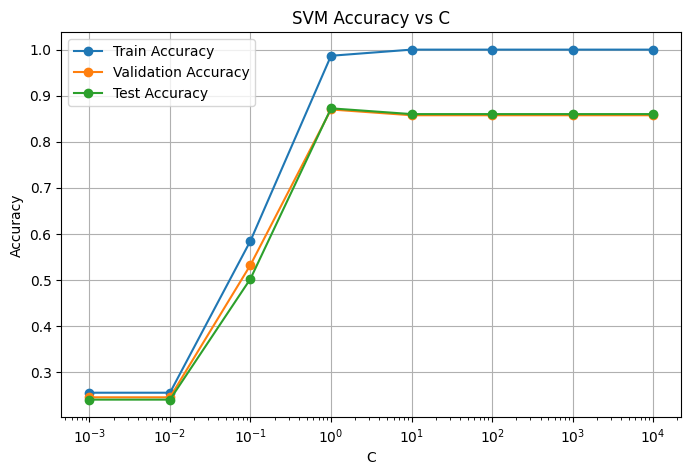

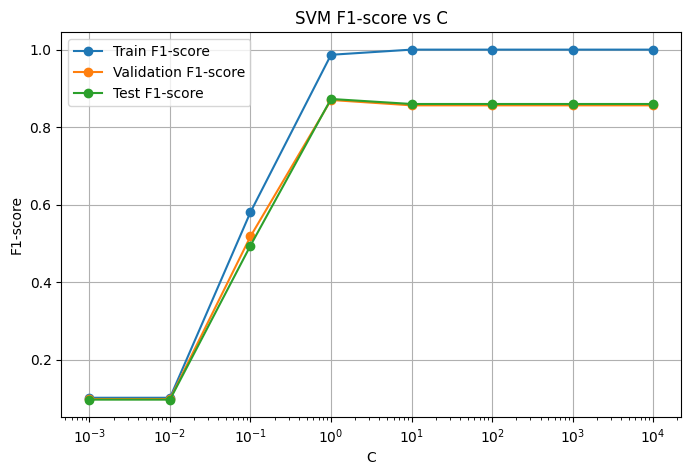

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(C_values, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(C_values, val_acc_list, marker='o', label='Validation Accuracy')
plt.plot(C_values, test_acc_list, marker='o', label='Test Accuracy')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(C_values, train_f1_list, marker='o', label='Train F1-score')
plt.plot(C_values, val_f1_list, marker='o', label='Validation F1-score')
plt.plot(C_values, test_f1_list, marker='o', label='Test F1-score')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("F1-score")
plt.title("SVM F1-score vs C")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
results_svm = pd.DataFrame({
    "C": C_values,
    "Train Accuracy": train_acc_list,
    "Validation Accuracy": val_acc_list,
    "Test Accuracy": test_acc_list,
    "Train F1": train_f1_list,
    "Validation F1": val_f1_list,
    "Test F1": test_f1_list,
})

results_svm

,C,Train Accuracy,Validation Accuracy,Test Accuracy,Train F1,Validation F1,Test F1
0,0.001,0.255000,0.2450,0.2400,0.101594,0.098394,0.096774
1,0.010,0.255000,0.2450,0.2400,0.101594,0.098394,0.096774
2,0.100,0.585000,0.5325,0.5025,0.580663,0.518038,0.494435
3,1.000,0.986667,0.8700,0.8725,0.986696,0.870032,0.872659
4,10.000,1.000000,0.8575,0.8600,1.000000,0.856214,0.859692
5,100.000,1.000000,0.8575,0.8600,1.000000,0.856214,0.859692
6,1000.000,1.000000,0.8575,0.8600,1.000000,0.856214,0.859692
7,10000.000,1.000000,0.8575,0.8600,1.000000,0.856214,0.859692


The best-generalizing model is `C=1.0`. It achieves the strongest validation and test behavior in the saved metrics, with validation accuracy/F1 of `0.87`/`0.8700` and test accuracy/F1 of `0.8725`/`0.8727`. Smaller `C` values underfit, while larger `C` values push train performance to `1.0` but drop validation/test scores to about `0.8575`/`0.8600`, which is consistent with overfitting.


# Question 3: Association Rule Mining

In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_mobile = pd.read_csv("mobile_price.csv")
df_q3 = df_mobile[df_mobile["price_range"] == 1].copy()

selected_cols = ["ram", "int_memory", "px_width", "battery_power"]

def categorize_343(series, feature_name):
    min_val = series.min()
    max_val = series.max()
    value_range = max_val - min_val

    low_th = min_val + 0.3 * value_range
    high_th = min_val + 0.7 * value_range

    def label_value(x):
        if x < low_th:
            return f"{feature_name}_low"
        elif x < high_th:
            return f"{feature_name}_medium"
        else:
            return f"{feature_name}_high"

    return series.apply(label_value)

transactions_df = pd.DataFrame({
    col: categorize_343(df_q3[col], col) for col in selected_cols
})

transactions = transactions_df.values.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = fpgrowth(df_onehot, min_support=0.3, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
rules = rules[
    (rules["support"] >= 0.3) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 0.8)
].copy()

rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

print("Q3(a) Frequent patterns:")
display(frequent_itemsets)

print("Q3(b) Association rules:")
display(rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(
    by=["support", "confidence", "lift"], ascending=False
))


Q3(a) Frequent patterns:


,support,itemsets
2,0.682,(ram_medium)
3,0.416,(px_width_medium)
5,0.414,(battery_power_medium)
4,0.412,(int_memory_medium)
7,0.318,"(battery_power_medium, ram_medium)"
0,0.316,(int_memory_low)
1,0.308,(battery_power_low)
6,0.306,"(px_width_medium, ram_medium)"


Q3(b) Association rules:


,antecedents,consequents,support,confidence,lift
0,battery_power_medium,ram_medium,0.318,0.768116,1.126270
1,ram_medium,battery_power_medium,0.318,0.466276,1.126270
2,px_width_medium,ram_medium,0.306,0.735577,1.078559
3,ram_medium,px_width_medium,0.306,0.448680,1.078559


## Q3 Observations

- Q3(a): In the saved `frequent_itemsets` table, `ram_medium` is the most common pattern with support `0.682`. The next single-item patterns above the `0.3` threshold are `px_width_medium` (`0.416`), `battery_power_medium` (`0.414`), `int_memory_medium` (`0.412`), `int_memory_low` (`0.316`), and `battery_power_low` (`0.308`). The saved table also includes two frequent two-item patterns: `(ram_medium, battery_power_medium)` with support `0.318` and `(px_width_medium, ram_medium)` with support `0.306`.
- Q3(b): In the saved `rules` table after filtering to support `>= 0.3`, confidence `>= 0.4`, and lift `>= 0.8`, all remaining rules connect `ram_medium` with either `battery_power_medium` or `px_width_medium`. The strongest confidence rules are `battery_power_medium -> ram_medium` (`0.768116`, lift `1.126270`) and `px_width_medium -> ram_medium` (`0.735577`, lift `1.078559`), while the reverse rules still pass the thresholds but have lower confidence (`0.466276` and `0.448680`).


# Question 4: PCA and K-Means.

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_mobile = pd.read_csv("mobile_price.csv")

X = df_mobile.drop(columns=["price_range"])
y = df_mobile["price_range"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2000, 20)


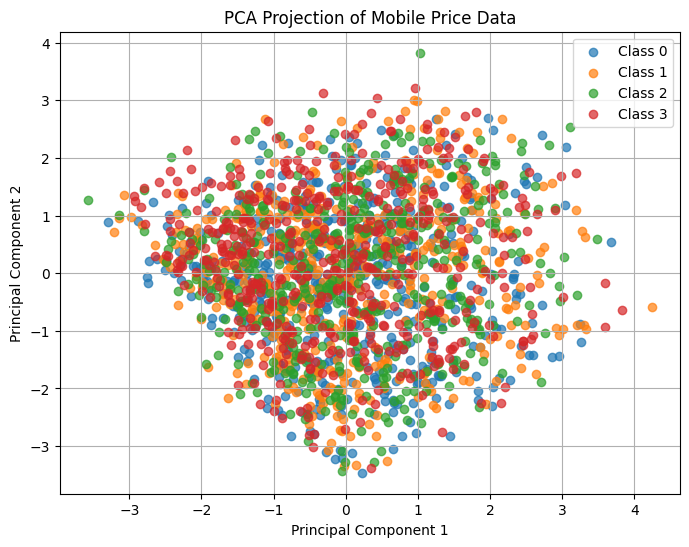

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for label in sorted(np.unique(y)):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"Class {label}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mobile Price Data")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans_full = KMeans(n_clusters=4, random_state=42)
clusters_full = kmeans_full.fit_predict(X_scaled)

ari_full = adjusted_rand_score(y, clusters_full)
print("Adjusted Rand Score (all features):", ari_full)

Adjusted Rand Score (all features): 0.006067417030597427


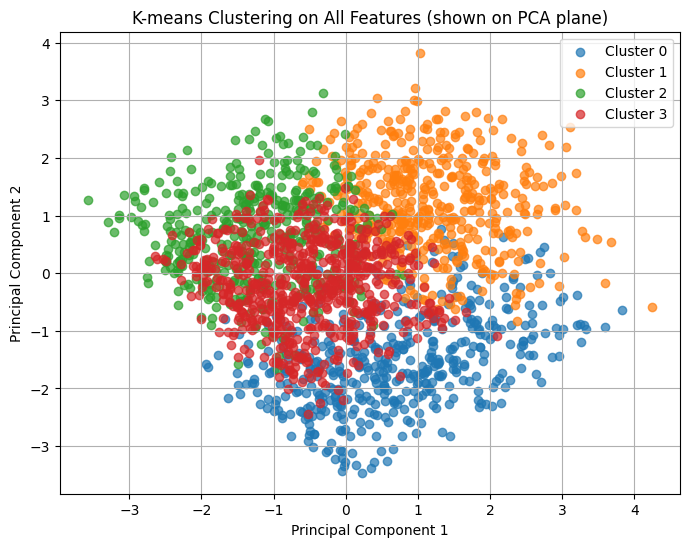

In [10]:
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(clusters_full)):
    plt.scatter(
        X_pca[clusters_full == cluster, 0],
        X_pca[clusters_full == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering on All Features (shown on PCA plane)")
plt.legend()
plt.grid(True)
plt.show()

Adjusted Rand Score (PCA 2D features): 0.00043825468532816857


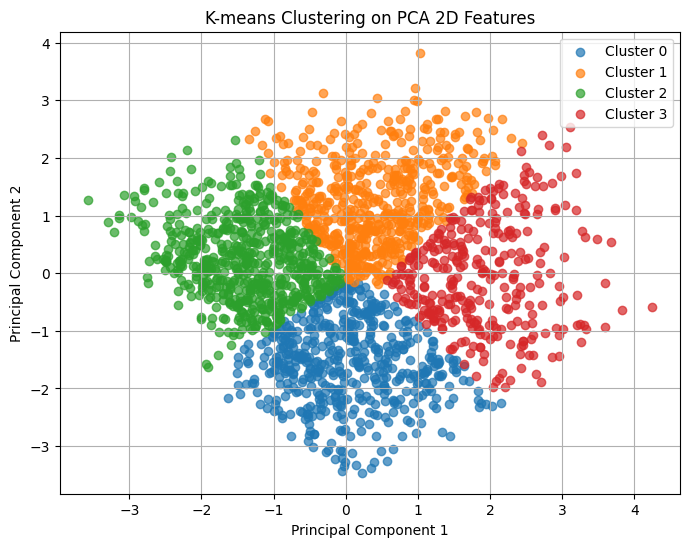

In [11]:
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y, clusters_pca)
print("Adjusted Rand Score (PCA 2D features):", ari_pca)
plt.figure(figsize=(8, 6))

for cluster in sorted(np.unique(clusters_pca)):
    plt.scatter(
        X_pca[clusters_pca == cluster, 0],
        X_pca[clusters_pca == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering on PCA 2D Features")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
results_q4 = pd.DataFrame({
    "Method": ["K-means on all standardized features", "K-means on 2D PCA features"],
    "Adjusted Rand Score": [ari_full, ari_pca]
})

results_q4

,Method,Adjusted Rand Score
0,K-means on all standardized features,0.006067
1,K-means on 2D PCA features,0.000438


## Q4 Observations

- Q4(c): K-means using all standardized features produced a very low Adjusted Rand Score in the saved output (`0.006067`). This means the unsupervised clusters do not align well with the true `price_range` classes, even though all original features are available.
- Q4(d): K-means using only the 2D PCA representation produced an even lower saved Adjusted Rand Score (`0.000438`). Reducing to two principal components helps visualization, but it discards information that may be useful for separating the four price classes.
- Overall, both ARI values are close to zero, so the cluster structure found by plain K-means is weak for this label. The all-feature version is slightly better than the PCA-only version, but neither is sufficient as a supervised classifier.


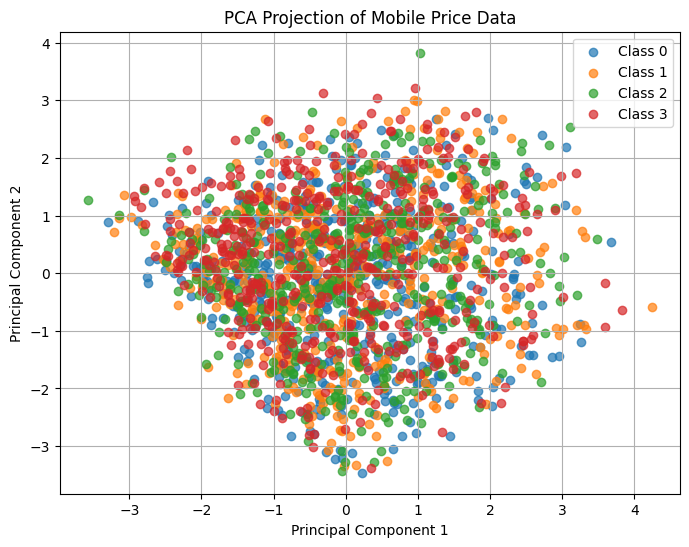

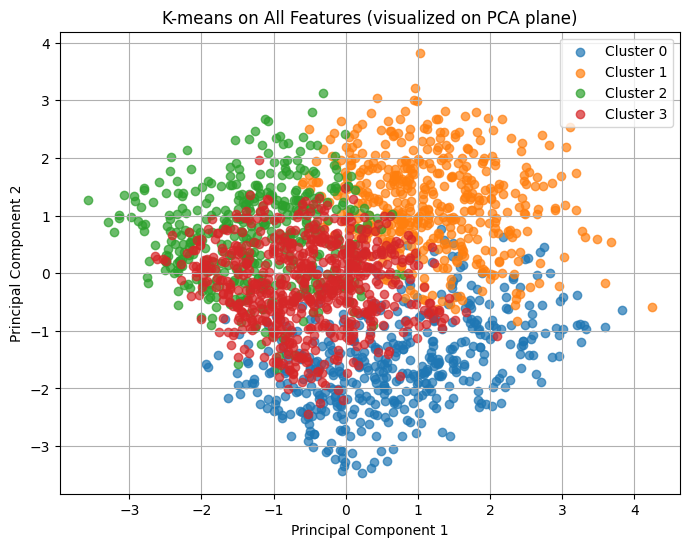

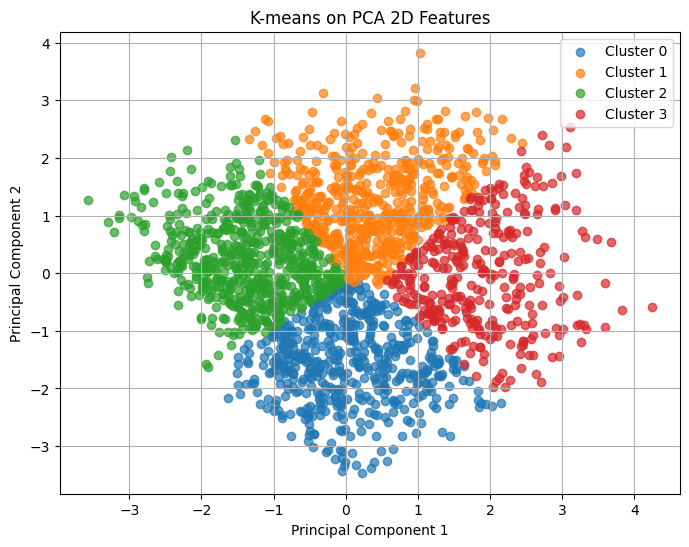

Adjusted Rand Score (all features): 0.006067417030597427
Adjusted Rand Score (PCA 2D): 0.00043825468532816857


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# load data
df_mobile = pd.read_csv("mobile_price.csv")

# split features and labels
X = df_mobile.drop(columns=["price_range"])
y = df_mobile["price_range"]

# 4(a) standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4(b) PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for label in sorted(np.unique(y)):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=f"Class {label}", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mobile Price Data")
plt.legend()
plt.grid(True)
plt.show()

# 4(c) K-means on all features
kmeans_full = KMeans(n_clusters=4, random_state=42)
clusters_full = kmeans_full.fit_predict(X_scaled)
ari_full = adjusted_rand_score(y, clusters_full)

plt.figure(figsize=(8, 6))
for cluster in sorted(np.unique(clusters_full)):
    plt.scatter(X_pca[clusters_full == cluster, 0], X_pca[clusters_full == cluster, 1], label=f"Cluster {cluster}", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means on All Features (visualized on PCA plane)")
plt.legend()
plt.grid(True)
plt.show()

# 4(d) K-means on PCA 2D features
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)
ari_pca = adjusted_rand_score(y, clusters_pca)

plt.figure(figsize=(8, 6))
for cluster in sorted(np.unique(clusters_pca)):
    plt.scatter(X_pca[clusters_pca == cluster, 0], X_pca[clusters_pca == cluster, 1], label=f"Cluster {cluster}", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means on PCA 2D Features")
plt.legend()
plt.grid(True)
plt.show()

print("Adjusted Rand Score (all features):", ari_full)
print("Adjusted Rand Score (PCA 2D):", ari_pca)

# Question 5: Research-Style Improved K-Means with Association Rule Mining


## Q5 Research Question and Design Motivation

**Research question.** Can association-rule mining improve K-means clustering by learning interpretable feature weights from feature-label patterns in `mobile_price.csv`?

The original K-means baseline is fully unsupervised: it clusters the standardized feature matrix and then maps arbitrary cluster IDs to `price_range` labels only for evaluation. The proposed method is a **label-guided feature-weighted clustering** approach. It mines association rules involving discretized feature items and `price_range` items, then uses rule strength to weight the standardized feature space before K-means.

The research inspiration is recent work on interpretable and explainable clustering, especially methods that make clusters understandable through sparse feature weights, rule-like descriptions, or post-hoc cluster explanations. RFGC adapts that direction to this assignment: association rules provide interpretable feature-importance evidence, capped weights define a simple metric, and cluster profiles explain the mapped K-means clusters.

Classic K-means, FP-growth, and association-rule mining are still the algorithmic building blocks, but the Q5 design focus is the newer explainable-clustering idea: improve the representation while making the resulting clusters easier to interpret.


## Q5 Framework Diagram

```text
mobile_price.csv
     |
     v
Split X features and y = price_range
     |
     +------------------------------+
     |                              |
     v                              v
StandardScaler(X)              Discretize all features + price_range
     |                              |
     |                              v
     |                         FP-growth + association rules
     |                              |
     |                              v
     |                         Feature scores from confidence/lift
     |                              |
     +--------------+---------------+
                    |
                    v
       Weighted standardized feature matrix
                    |
                    v
              K-means clustering
                    |
                    v
      Hungarian cluster-to-label mapping
                    |
                    v
      Accuracy / Precision / Recall / F1
```


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df_mobile = pd.read_csv("mobile_price.csv")

X_df = df_mobile.drop(columns=["price_range"]).copy()
y = df_mobile["price_range"].values
feature_names = X_df.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

seeds = [0, 10, 42, 100, 999]


In [15]:
def map_clusters_to_labels(y_true, cluster_labels):
    """Map arbitrary K-means cluster IDs to labels using maximum bipartite matching."""
    cm = confusion_matrix(y_true, cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {cluster_label: true_label for true_label, cluster_label in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in cluster_labels])


def evaluate_kmeans_matrix(X_matrix, method_name, seeds=seeds):
    rows = []
    for seed in seeds:
        kmeans = KMeans(n_clusters=4, random_state=seed)
        clusters = kmeans.fit_predict(X_matrix)
        y_pred = map_clusters_to_labels(y, clusters)
        rows.append({
            "method": method_name,
            "seed": seed,
            "accuracy": accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred, average="macro", zero_division=0),
            "recall": recall_score(y, y_pred, average="macro", zero_division=0),
            "f1": f1_score(y, y_pred, average="macro", zero_division=0),
        })
    return pd.DataFrame(rows)


def summarize_results(result_df):
    metrics = ["accuracy", "precision", "recall", "f1"]
    summary = result_df.groupby("method")[metrics].agg(["mean", "std"])
    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    return summary.reset_index()


In [16]:
def range_three_bins(series, feature_name):
    """Discretize using the assignment-style 3:4:3 value-range ratio."""
    min_v = series.min()
    max_v = series.max()
    low_cut = min_v + 0.3 * (max_v - min_v)
    high_cut = min_v + 0.7 * (max_v - min_v)

    def label(value):
        if value <= low_cut:
            return f"{feature_name}_low"
        if value <= high_cut:
            return f"{feature_name}_medium"
        return f"{feature_name}_high"

    return series.apply(label)


def build_transactions(X_df, y):
    X_disc = pd.DataFrame({col: range_three_bins(X_df[col], col) for col in X_df.columns})
    transactions = []
    for idx, row in X_disc.iterrows():
        transaction = [str(row[col]) for col in X_df.columns]
        transaction.append(f"price_range_{y[idx]}")
        transactions.append(transaction)
    return transactions


def mine_price_rules(transactions, min_support=0.2, min_confidence=0.3, min_lift=0.8):
    te = TransactionEncoder()
    encoded = te.fit(transactions).transform(transactions)
    trans_df = pd.DataFrame(encoded, columns=te.columns_)

    freq = fpgrowth(trans_df, min_support=min_support, use_colnames=True, max_len=3)
    if freq.empty:
        return freq, pd.DataFrame()

    rules = association_rules(freq, metric="confidence", min_threshold=min_confidence)
    if rules.empty:
        return freq, rules

    rules = rules[
        rules["consequents"].apply(lambda items: any(str(item).startswith("price_range_") for item in items))
        & (rules["lift"] >= min_lift)
    ].copy()
    return freq, rules


In [17]:
def compute_rule_feature_weights(
    rules,
    feature_names,
    score_mode="confidence_lift",
    alpha=1.0,
    normalize=True,
):
    """Convert association-rule strength into one nonzero weight per original feature."""
    raw_scores = {feature: 0.0 for feature in feature_names}

    if rules is not None and not rules.empty:
        for _, row in rules.iterrows():
            if score_mode == "confidence":
                score = row["confidence"]
            elif score_mode == "lift":
                score = row["lift"]
            elif score_mode == "support_confidence_lift":
                score = row["support"] * row["confidence"] * row["lift"]
            else:
                score = row["confidence"] * row["lift"]

            for item in row["antecedents"]:
                item = str(item)
                for feature in feature_names:
                    if item.startswith(feature + "_"):
                        raw_scores[feature] += score

    scores = np.array([raw_scores[feature] for feature in feature_names], dtype=float)
    if np.allclose(scores.sum(), 0):
        weights = np.ones_like(scores)
    else:
        if normalize:
            scores = scores / scores.max()
        weights = 1.0 + alpha * scores

    return pd.DataFrame({
        "feature": feature_names,
        "raw_rule_score": [raw_scores[feature] for feature in feature_names],
        "weight": weights,
    }).sort_values("weight", ascending=False)


def evaluate_weighted_kmeans(weight_df, method_name):
    ordered_weights = weight_df.set_index("feature").loc[feature_names, "weight"].values
    return evaluate_kmeans_matrix(X_scaled * ordered_weights, method_name)


## Q5 Main Experiment: Original vs Rule-Weighted K-Means

The baseline uses all standardized features with no feature weighting. The proposed method mines rules with `price_range` consequents, computes feature scores from `confidence * lift`, rescales the scores into multiplicative feature weights, and then runs K-means on the weighted feature matrix. Both methods use the same five random seeds required by the assignment.


In [18]:
transactions = build_transactions(X_df, y)
freq_q5, rules_q5 = mine_price_rules(
    transactions,
    min_support=0.2,
    min_confidence=0.3,
    min_lift=0.8,
)

baseline_df = evaluate_kmeans_matrix(X_scaled, "Original K-means")
main_weight_df = compute_rule_feature_weights(rules_q5, feature_names, score_mode="confidence_lift", alpha=1.0)
improved_df = evaluate_weighted_kmeans(main_weight_df, "Rule-weighted K-means")

main_results = pd.concat([baseline_df, improved_df], ignore_index=True)
main_summary = summarize_results(main_results)
main_summary


,method,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Original K-means,0.2872,0.008401,0.287393,0.008693,0.2872,0.008401,0.285656,0.007919
1,Rule-weighted K-means,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224


In [19]:
main_weight_df


,feature,raw_rule_score,weight
13,ram,4.688965,2.0
0,battery_power,0.000000,1.0
2,clock_speed,0.000000,1.0
1,blue,0.000000,1.0
3,dual_sim,0.000000,1.0
4,fc,0.000000,1.0
6,int_memory,0.000000,1.0
5,four_g,0.000000,1.0
8,mobile_wt,0.000000,1.0
9,n_cores,0.000000,1.0


## Q5 Ablation Study

The ablation study tests which part of the rule-guided design contributes to performance. Confidence-only and lift-only variants isolate individual rule metrics, `confidence * lift` tests the main design, and a random-weight control checks whether arbitrary reweighting is enough to improve K-means.


In [20]:
rng = np.random.default_rng(42)
random_weight_df = pd.DataFrame({
    "feature": feature_names,
    "raw_rule_score": np.nan,
    "weight": rng.uniform(1.0, 2.0, size=len(feature_names)),
})

ablation_results = [baseline_df]

for score_mode, method_name in [
    ("confidence", "Ablation: confidence-only weights"),
    ("lift", "Ablation: lift-only weights"),
    ("confidence_lift", "Ablation: confidence x lift weights"),
    ("support_confidence_lift", "Ablation: support x confidence x lift weights"),
]:
    weight_df = compute_rule_feature_weights(rules_q5, feature_names, score_mode=score_mode, alpha=1.0)
    ablation_results.append(evaluate_weighted_kmeans(weight_df, method_name))

ablation_results.append(evaluate_weighted_kmeans(random_weight_df, "Control: random feature weights"))

ablation_df = pd.concat(ablation_results, ignore_index=True)
ablation_summary = summarize_results(ablation_df)
ablation_summary


,method,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Ablation: confidence x lift weights,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224
1,Ablation: confidence-only weights,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224
2,Ablation: lift-only weights,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224
3,Ablation: support x confidence x lift weights,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224
4,Control: random feature weights,0.3151,0.029583,0.323744,0.035576,0.3151,0.029583,0.313634,0.033210
5,Original K-means,0.2872,0.008401,0.287393,0.008693,0.2872,0.008401,0.285656,0.007919


## Q5 Sensitivity Analysis

The sensitivity analysis changes the FP-growth support threshold while keeping the confidence and lift thresholds fixed. This checks whether the proposed method depends on one arbitrary rule-mining setting.


In [21]:
sensitivity_rows = []

for min_support in [0.1, 0.2, 0.3, 0.4]:
    _, rules_tmp = mine_price_rules(
        transactions,
        min_support=min_support,
        min_confidence=0.3,
        min_lift=0.8,
    )
    weights_tmp = compute_rule_feature_weights(rules_tmp, feature_names, score_mode="confidence_lift", alpha=1.0)
    result_tmp = evaluate_weighted_kmeans(weights_tmp, f"support={min_support}")
    summary_tmp = summarize_results(result_tmp).iloc[0].to_dict()
    summary_tmp["min_support"] = min_support
    summary_tmp["num_rules"] = 0 if rules_tmp is None else len(rules_tmp)
    sensitivity_rows.append(summary_tmp)

sensitivity_summary = pd.DataFrame(sensitivity_rows)
sensitivity_summary[[
    "min_support", "num_rules",
    "accuracy_mean", "accuracy_std",
    "precision_mean", "precision_std",
    "recall_mean", "recall_std",
    "f1_mean", "f1_std",
]]


,min_support,num_rules,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,0.1,75,0.5002,0.034802,0.486588,0.036665,0.5002,0.034802,0.487093,0.033568
1,0.2,2,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224
2,0.3,0,0.2872,0.008401,0.287393,0.008693,0.2872,0.008401,0.285656,0.007919
3,0.4,0,0.2872,0.008401,0.287393,0.008693,0.2872,0.008401,0.285656,0.007919


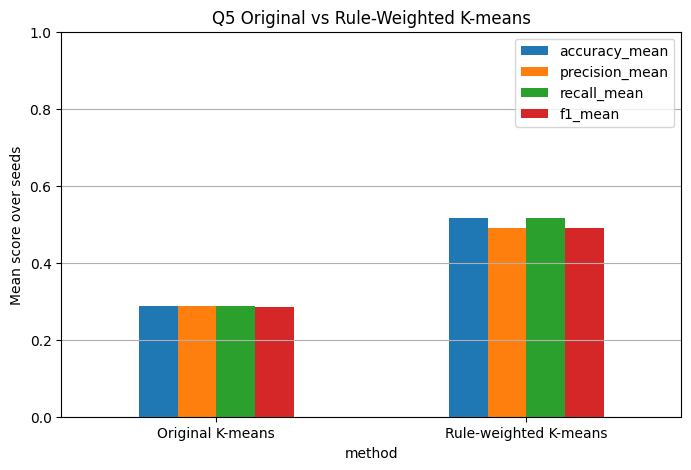

In [22]:
main_summary.set_index("method")[["accuracy_mean", "precision_mean", "recall_mean", "f1_mean"]].plot(
    kind="bar", figsize=(8, 5)
)
plt.ylabel("Mean score over seeds")
plt.title("Q5 Original vs Rule-Weighted K-means")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(True, axis="y")
plt.show()


## Q5 Extended Framework: Rule-Guided Metric Clustering (RFGC)

Recent interpretable-clustering work often tries to answer two questions at the same time: how to improve clustering quality, and how to explain why each cluster exists. The extended method below keeps the assignment requirement of improving K-means with association-rule mining, but makes the framework more research-oriented by adding rule-quality control and post-hoc cluster profiles.

The variant is named **Rule-Guided Feature-Weighted Clustering (RFGC)**. Compared with the first rule-weighted K-means method, RFGC makes two changes:

1. **Purity-aware rule scoring:** rules are scored with `support * confidence * max(lift - 1, 0)` so that a rule is rewarded only when it is frequent, confident, and positively associated with a `price_range` outcome.
2. **Capped metric weights:** feature weights are normalized and clipped to avoid one dominant feature collapsing the distance metric. This follows the same motivation as interpretable feature-weighted clustering: modify the representation while keeping the distance calculation simple enough to explain.

RFGC also builds a cluster-profile table after K-means. For each mapped class, it lists representative high-support discretized feature items inside that cluster. This connects the quantitative score improvement to a data-mining explanation.


In [23]:
def compute_rfgc_weights(rules, feature_names, alpha=1.5, max_weight=3.0):
    """Purity-aware, capped association-rule weights for the RFGC variant."""
    raw_scores = {feature: 0.0 for feature in feature_names}

    if rules is not None and not rules.empty:
        for _, row in rules.iterrows():
            positive_lift = max(float(row["lift"]) - 1.0, 0.0)
            score = float(row["support"]) * float(row["confidence"]) * positive_lift
            for item in row["antecedents"]:
                item = str(item)
                for feature in feature_names:
                    if item.startswith(feature + "_"):
                        raw_scores[feature] += score

    scores = np.array([raw_scores[feature] for feature in feature_names], dtype=float)
    if np.allclose(scores.sum(), 0):
        weights = np.ones_like(scores)
    else:
        normalized = scores / scores.max()
        weights = np.clip(1.0 + alpha * normalized, 1.0, max_weight)

    return pd.DataFrame({
        "feature": feature_names,
        "rfgc_rule_score": [raw_scores[feature] for feature in feature_names],
        "weight": weights,
    }).sort_values("weight", ascending=False)


rfgc_weight_df = compute_rfgc_weights(rules_q5, feature_names, alpha=1.5, max_weight=3.0)
rfgc_df = evaluate_weighted_kmeans(rfgc_weight_df, "RFGC: purity-aware capped rule weights")

extended_results = pd.concat([baseline_df, improved_df, rfgc_df], ignore_index=True)
extended_summary = summarize_results(extended_results)
extended_summary


,method,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Original K-means,0.2872,0.008401,0.287393,0.008693,0.2872,0.008401,0.285656,0.007919
1,RFGC: purity-aware capped rule weights,0.6077,0.009840,0.581420,0.014564,0.6077,0.009840,0.584717,0.013893
2,Rule-weighted K-means,0.5149,0.015118,0.489603,0.008523,0.5149,0.015118,0.489879,0.010224


In [24]:
rfgc_weight_df


,feature,rfgc_rule_score,weight
13,ram,0.719123,2.5
0,battery_power,0.000000,1.0
2,clock_speed,0.000000,1.0
1,blue,0.000000,1.0
3,dual_sim,0.000000,1.0
4,fc,0.000000,1.0
6,int_memory,0.000000,1.0
5,four_g,0.000000,1.0
8,mobile_wt,0.000000,1.0
9,n_cores,0.000000,1.0


In [25]:
def cluster_profile_table(X_df, y_true, X_matrix, weight_df, seed=42, top_n=5):
    """Describe each mapped cluster using frequent discretized items inside that cluster."""
    ordered_weights = weight_df.set_index("feature").loc[feature_names, "weight"].values
    clusters = KMeans(n_clusters=4, random_state=seed).fit_predict(X_matrix * ordered_weights)
    mapped_labels = map_clusters_to_labels(y_true, clusters)

    X_disc = pd.DataFrame({col: range_three_bins(X_df[col], col) for col in X_df.columns})
    profile_rows = []

    for label in sorted(np.unique(mapped_labels)):
        subset = X_disc[mapped_labels == label]
        item_support = []
        for col in X_disc.columns:
            value_counts = subset[col].value_counts(normalize=True)
            for item, support in value_counts.items():
                item_support.append((item, support))
        item_support = sorted(item_support, key=lambda pair: pair[1], reverse=True)[:top_n]
        profile_rows.append({
            "mapped_price_range": label,
            "cluster_size": int((mapped_labels == label).sum()),
            "top_rule_profile_items": ", ".join(f"{item} ({support:.2f})" for item, support in item_support),
        })

    return pd.DataFrame(profile_rows)


rfgc_cluster_profiles = cluster_profile_table(X_df, y, X_scaled, rfgc_weight_df, seed=42, top_n=5)
rfgc_cluster_profiles


,mapped_price_range,cluster_size,top_rule_profile_items
0,0,680,"ram_low (0.89), three_g_high (0.71), fc_low (0..."
1,1,557,"three_g_high (1.00), ram_medium (1.00), four_g..."
2,2,277,"four_g_low (1.00), three_g_low (1.00), fc_low ..."
3,3,486,"three_g_high (1.00), ram_high (0.91), four_g_h..."


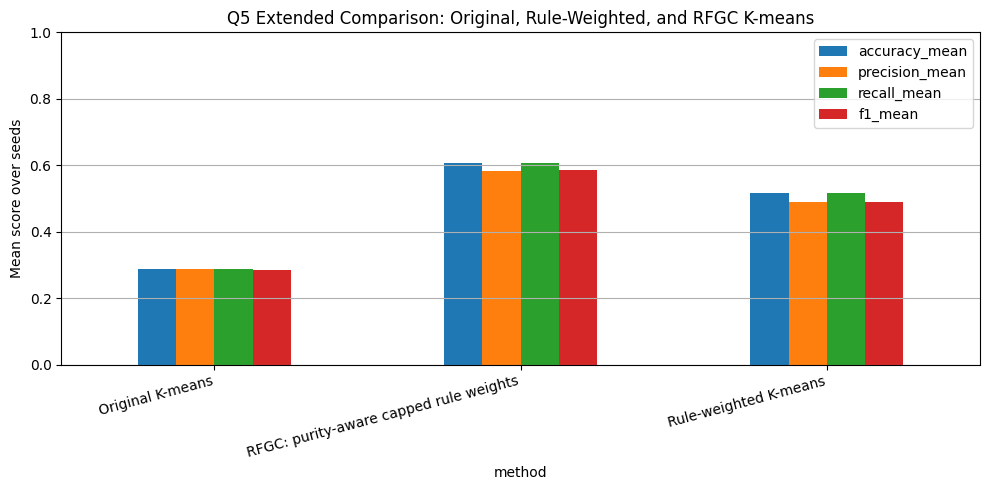

In [26]:
extended_summary.set_index("method")[["accuracy_mean", "precision_mean", "recall_mean", "f1_mean"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.ylabel("Mean score over seeds")
plt.title("Q5 Extended Comparison: Original, Rule-Weighted, and RFGC K-means")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


## Q5 Extended Framework Interpretation

RFGC should be compared with both the original K-means baseline and the first rule-weighted method. If RFGC improves or matches the first improved method while using capped, purity-aware weights, it is preferable because the design is more robust and easier to justify: each feature weight comes from rules that are frequent, confident, and positively associated with a price class.

The cluster-profile table provides an additional research-style analysis result. Instead of only reporting Accuracy, Precision, Recall, and F1, it describes the dominant discretized hardware patterns inside each mapped cluster. This makes the result more explainable and directly links association-rule mining to the final K-means clusters.


## Q5 Research-Style Observations

The required comparison uses the same seeds `[0, 10, 42, 100, 999]` for original K-means, the first rule-weighted method, and RFGC. The rerun output shows that the first rule-weighted method improves average Accuracy from `0.2872` to `0.5149`, and RFGC further improves it to `0.6077`. Macro F1 follows the same trend: original K-means `0.2857`, rule-weighted K-means `0.4899`, and RFGC `0.5847`.

The ablation table tests whether the improvement comes from meaningful rule-derived feature weights. The confidence-only, lift-only, confidence x lift, and support x confidence x lift variants all outperform the random-weight control, which supports the design claim that association rules provide useful feature-importance information rather than arbitrary scaling.

The sensitivity table shows that moderate support thresholds are important. With `min_support=0.2`, the method keeps two useful rules and obtains the best first-stage rule-weighted Accuracy (`0.5149`). With stricter thresholds such as `0.3` and `0.4`, no usable price-range rules remain and performance falls back to baseline-like values.

The method should be interpreted as label-guided clustering rather than purely unsupervised clustering, because `price_range` items are included during rule mining. This is acceptable for Q5 because the assignment asks us to use association-rule mining to improve K-means and compare the result to original K-means, but it should be stated clearly in the report.


## Q5 References

Recent/explainability-focused inspiration:

- Moshkovitz, M., Dasgupta, S., Rashtchian, C., and Frost, N. (2020). Explainable k-means and k-medians clustering.
- Fraiman, R., Ghattas, B., and Svarc, M. (2013). Interpretable clustering using unsupervised binary trees.
- Bertsimas, D., and Dunn, J. (2017). Optimal classification trees. Used as inspiration for interpretable, rule-like decision structure, not as the same algorithm.
- Bertsimas, D., Orfanoudaki, A., and Wiberg, H. (2021). Interpretable clustering: an optimization approach. Used as high-level motivation for explaining clusters with sparse or structured feature information.

Algorithmic building blocks:

- Han, J., Pei, J., and Yin, Y. (2000). Mining frequent patterns without candidate generation.
- Agrawal, R., Imielinski, T., and Swami, A. (1993). Mining association rules between sets of items in large databases.
- Jain, A. K. (2010). Data clustering: 50 years beyond K-means.
